# 05 — Constraints: Steering Folding with Prior Knowledge

## Learning objectives

By the end of this notebook you will be able to:

- Explain the difference between **hard constraints** (restrict the search
  space) and **soft constraints** (bias the energy landscape without
  forbidding anything).
- Force positions to be paired, unpaired, or paired to a specific partner
  using `hc_add_from_db` and `hc_add_bp`, and read the resulting change in
  MFE structure and energy.
- Add a pseudo-energy bonus/penalty with `sc_add_bp`/`sc_add_up`, and find the
  bonus magnitude needed to change which structure is optimal.
- Connect a constraint's energetic cost back to the **base-pair probabilities**
  from notebook 3 — a "cheap" constraint targets a structure the ensemble
  already favors.

**Prerequisites**: [02_mfe_folding.ipynb](02_mfe_folding.ipynb) (`eval_structure`,
energy units) and [03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
(the competing-structure sequence and its base-pair probabilities, used again
below).


## 1. Introduction & motivation

Every notebook so far has folded a sequence "as is" — letting the
nearest-neighbor model alone decide the structure. In practice you often know
*something* about the structure already: a chemical-probing experiment
(SHAPE/DMS) suggests certain positions are unpaired, a comparative-genomics
study or crystal structure establishes a specific base pair, or you simply
want to ask "if this region *couldn't* form a helix, what would the molecule
do instead?"

**Constraints** let you fold *with* that prior knowledge rather than
discarding it. ViennaRNA offers two kinds, with very different semantics:

- **Hard constraints** *forbid* certain structures outright — folding proceeds
  exactly as before, but only over the reduced set of structures that satisfy
  the constraint.
- **Soft constraints** *do not forbid anything* — they add a position- or
  pair-specific energy bonus/penalty, shifting which structure has the lowest
  total (model + bonus) energy. This is the mechanism used to incorporate
  quantitative experimental reactivity data (e.g. SHAPE).

**Roadmap**: theory first (what each constraint type changes mathematically),
then worked examples — hard-constraining individual positions and base pairs
on the sequences from notebooks 3–4, sweeping a soft-constraint bonus until
the optimal structure switches, and a case study combining both.


## 2. Theoretical background

### 2.1 Hard constraints: restricting $\Omega(x)$

Recall from notebook 2 that folding minimizes $\Delta G(s\mid x)$ over the set
$\Omega(x)$ of all secondary structures compatible with $x$. A hard constraint
$C$ defines a subset $\Omega_C(x) \subseteq \Omega(x)$ — e.g. "structures in
which position 5 is unpaired" or "structures containing the pair $(3,18)$" —
and folding becomes

$$
s^*_C \;=\; \arg\min_{s \,\in\, \Omega_C(x)} \Delta G(s\mid x).
$$

The energy function itself is **unchanged**; only the search space shrinks.
Consequently $\Delta G(s^*_C) \geq \Delta G(s^*)$ always — restricting the
search can only make the optimum worse (or leave it unchanged, if the
unconstrained MFE already satisfied $C$).

### 2.2 Soft constraints: biasing $\Delta G$

A soft constraint adds an extra term $c(s)$ — typically a sum of per-position
or per-pair pseudo-energies — to every structure's energy:

$$
\Delta G'(s\mid x) \;=\; \Delta G(s\mid x) + c(s), \qquad
s^*_{c} \;=\; \arg\min_{s \,\in\, \Omega(x)} \Delta G'(s\mid x).
$$

Nothing is forbidden ($\Omega(x)$ is unchanged); a sufficiently large bonus
$c(s) < 0$ for a particular pair can still make a structure containing that
pair the new optimum, if its bonus outweighs its energetic disadvantage
relative to the unconstrained MFE. This is exactly the mechanism used for
SHAPE-directed folding: each position's pseudo-energy is derived from its
measured chemical reactivity.

### 2.3 Theory-to-API map

| Constraint | Type | ViennaRNA API |
| :--- | :--- | :--- |
| Position $i$ must be unpaired | Hard | `hc_add_up(i)` or `hc_add_from_db("...x...")` |
| Pair $(i,j)$ must form | Hard | `hc_add_bp(i, j, RNA.CONSTRAINT_CONTEXT_ALL_LOOPS)` |
| Bulk constraint from a dot-bracket-like string (`.` free, `x` forced unpaired, `(`/`)` forced paired) | Hard | `hc_add_from_db(constraint_string)` |
| Energy bonus/penalty for position $i$ unpaired | Soft | `sc_add_up(i, energy)` |
| Energy bonus/penalty for pair $(i,j)$ | Soft | `sc_add_bp(i, j, energy)` |

All position arguments above are **1-indexed**, matching the convention used
by `hc_add_from_db`'s string positions (string index 0 = sequence position 1).


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def draw_structure(ax, sequence, structure, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()


## 3. Worked example 1 — forcing positions unpaired

Take the fraying hairpin from notebooks 3–4 (`GGGAAACCCAAAGGGAAACCC`, MFE
structure `(((...(((...)))...)))`). Position 1 is the outermost base of the
outer helix. What happens if we *force* it to be unpaired — and what if we
force the **entire outer helix** unpaired?


In [2]:
seq_1 = "GGGAAACCCAAAGGGAAACCC"

fc_baseline = RNA.fold_compound(seq_1)
structure_baseline, mfe_baseline = fc_baseline.mfe()

# Constraint A: force position 1 unpaired ('x' at string index 0).
fc_a = RNA.fold_compound(seq_1)
fc_a.hc_add_from_db("x" + "." * (len(seq_1) - 1))
structure_a, mfe_a = fc_a.mfe()

# Constraint B: force the entire outer helix (positions 1-3 and 19-21) unpaired.
fc_b = RNA.fold_compound(seq_1)
fc_b.hc_add_from_db("xxx" + "." * 15 + "xxx")
structure_b, mfe_b = fc_b.mfe()

results_1 = pd.DataFrame([
    {"constraint": "None (baseline)", "structure": structure_baseline, "mfe": mfe_baseline},
    {"constraint": "Position 1 unpaired", "structure": structure_a, "mfe": mfe_a},
    {"constraint": "Outer helix unpaired", "structure": structure_b, "mfe": mfe_b},
])
results_1


,constraint,structure,mfe
0,None (baseline),(((...(((...)))...))),-5.8
1,Position 1 unpaired,.((...(((...)))...)).,-3.5
2,Outer helix unpaired,......(((...)))......,-2.3


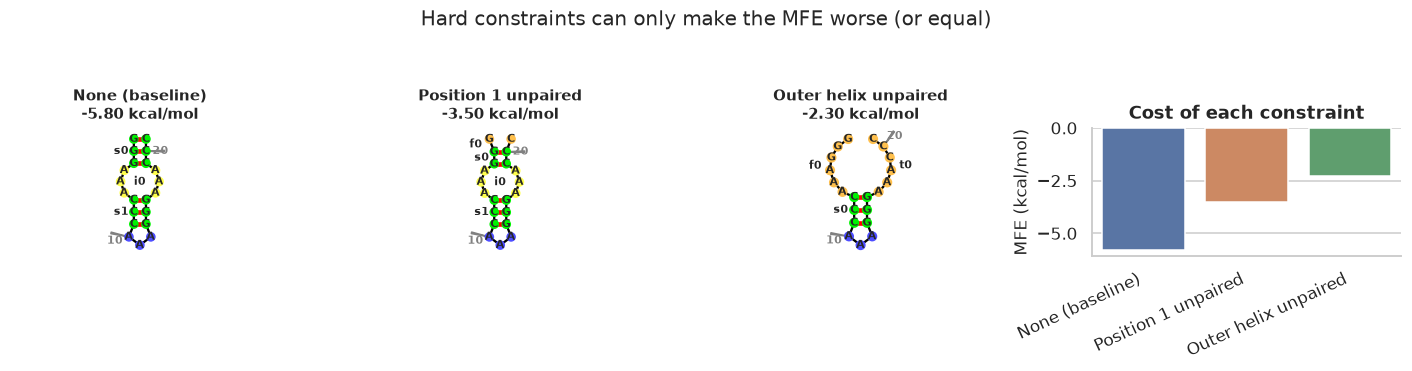

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.2]})

for ax, row in zip(axes[:3], results_1.itertuples()):
    draw_structure(ax, seq_1, row.structure, f"{row.constraint}\n{row.mfe:.2f} kcal/mol")

sns.barplot(data=results_1, x="constraint", y="mfe", hue="constraint",
            palette=PALETTE[:3], legend=False, ax=axes[3])
axes[3].set_ylabel("MFE (kcal/mol)")
axes[3].set_xlabel("")
axes[3].set_title("Cost of each constraint")
plt.setp(axes[3].get_xticklabels(), rotation=25, ha="right")
sns.despine(ax=axes[3])

fig.suptitle("Hard constraints can only make the MFE worse (or equal)", y=1.05, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: forcing just position 1 unpaired costs 2.3
kcal/mol — the outer helix shrinks from 3 base pairs to 2, but the rest of the
structure (including the entire inner hairpin) is unaffected. Forcing the
*whole* outer helix unpaired costs 3.5 kcal/mol and removes that helix
entirely, leaving only the inner hairpin. Both constrained energies are
$\geq$ the baseline $-5.80$ kcal/mol, exactly as Section 2.1 predicts — the
constrained search space is a *subset* of the unconstrained one.


## 4. Worked example 2 — forcing a specific base pair

Now revisit the competing-structure sequence from notebook 3
(`CCCCAAAAGGGGAAAACCCCAAAAGGGG`). Its MFE structure pairs the first C-tract
with the *nearer* G-tract ($-13.20$ kcal/mol), but notebook 3's dot plot showed
a substantial alternative — pairing instead with the *farther* G-tract — at
base-pair probability $\approx 0.42$. Hard-constraining that specific pair to
form should recover this alternative as the new (constrained) MFE.


In [4]:
seq_2 = "CCCCAAAAGGGGAAAACCCCAAAAGGGG"

fc_baseline_2 = RNA.fold_compound(seq_2)
structure_baseline_2, mfe_baseline_2 = fc_baseline_2.mfe()

# Force base pair (1, 28) -- the outermost positions -- to form.
fc_forced = RNA.fold_compound(seq_2)
fc_forced.hc_add_bp(1, len(seq_2), RNA.CONSTRAINT_CONTEXT_ALL_LOOPS)
structure_forced, mfe_forced = fc_forced.mfe()

print(f"Sequence:               {seq_2}")
print(f"Unconstrained MFE:      {structure_baseline_2}  ({mfe_baseline_2:.2f} kcal/mol)")
print(f"Forced pair (1,{len(seq_2)}):     {structure_forced}  ({mfe_forced:.2f} kcal/mol)")
print(f"Cost of the constraint: {mfe_forced - mfe_baseline_2:.2f} kcal/mol")


Sequence:               CCCCAAAAGGGGAAAACCCCAAAAGGGG
Unconstrained MFE:      ((((....))))....((((....))))  (-13.20 kcal/mol)
Forced pair (1,28):     ((((....((((....))))....))))  (-13.00 kcal/mol)
Cost of the constraint: 0.20 kcal/mol


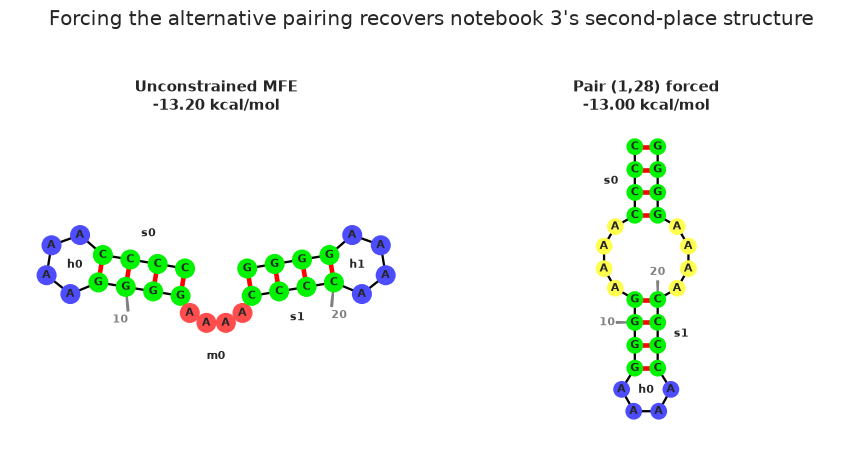

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
draw_structure(axes[0], seq_2, structure_baseline_2,
               f"Unconstrained MFE\n{mfe_baseline_2:.2f} kcal/mol")
draw_structure(axes[1], seq_2, structure_forced,
               f"Pair (1,{len(seq_2)}) forced\n{mfe_forced:.2f} kcal/mol")
fig.suptitle("Forcing the alternative pairing recovers notebook 3's second-place structure", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the constrained structure is the *exact*
alternative pairing notebook 3 identified at $p \approx 0.42$ — and it costs
only **0.20 kcal/mol** more than the unconstrained MFE. The size of this cost
is not a coincidence: it is the energetic counterpart of "this was already the
second-most-probable structure". A constraint that costs 0.2 kcal/mol targets
something the ensemble already does often; a constraint that costs 10 kcal/mol
targets something the ensemble essentially never does. **Hard-constraint cost
and ensemble probability are two views of the same thing.**


## 5. Worked example 3 — soft constraints: how big a bonus is enough?

Instead of *forcing* the pair $(1,28)$, add a **soft** constraint: an energy
*bonus* (negative pseudo-energy) for that pair forming, of varying magnitude.
For small bonuses, the unconstrained MFE structure should remain optimal
(the bonus doesn't apply, since that pair isn't in it); once the bonus exceeds
the 0.20 kcal/mol cost from Section 4, the alternative structure should become
the new MFE.


In [6]:
bonuses = np.round(np.arange(0, -0.55, -0.05), 2)
sweep_rows = []
for bonus in bonuses:
    fc = RNA.fold_compound(seq_2)
    fc.sc_add_bp(1, len(seq_2), float(bonus))
    structure, mfe = fc.mfe()
    sweep_rows.append({"bonus": bonus, "mfe": mfe, "structure": structure,
                        "is_alternative": structure == structure_forced})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df


,bonus,mfe,structure,is_alternative
0,0.00,-13.20,((((....))))....((((....)))),False
1,-0.05,-13.20,((((....))))....((((....)))),False
2,-0.10,-13.20,((((....))))....((((....)))),False
3,-0.15,-13.20,((((....))))....((((....)))),False
4,-0.20,-13.20,((((....))))....((((....)))),False
5,-0.25,-13.25,((((....((((....))))....)))),True
6,-0.30,-13.30,((((....((((....))))....)))),True
7,-0.35,-13.35,((((....((((....))))....)))),True
8,-0.40,-13.40,((((....((((....))))....)))),True
9,-0.45,-13.45,((((....((((....))))....)))),True


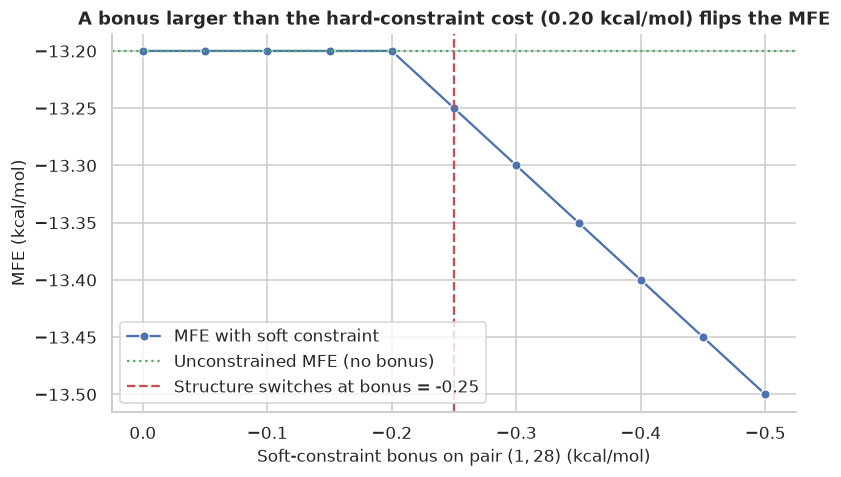

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.lineplot(data=sweep_df, x="bonus", y="mfe", marker="o", color=PALETTE[0], ax=ax,
             label="MFE with soft constraint")
ax.axhline(mfe_baseline_2, color=PALETTE[2], ls=":", lw=1.5, label="Unconstrained MFE (no bonus)")

switch_idx = sweep_df["is_alternative"].idxmax()
switch_bonus = sweep_df.loc[switch_idx, "bonus"]
ax.axvline(switch_bonus, color=PALETTE[3], ls="--", lw=1.5,
           label=f"Structure switches at bonus = {switch_bonus:.2f}")

ax.set_xlabel(r"Soft-constraint bonus on pair $(1, 28)$ (kcal/mol)")
ax.set_ylabel("MFE (kcal/mol)")
ax.set_title("A bonus larger than the hard-constraint cost (0.20 kcal/mol) flips the MFE")
ax.invert_xaxis()
ax.legend()
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Reading the figure**: for small bonuses (right side, near 0), the MFE
line tracks the unconstrained MFE exactly — the bonus is too small to change
which structure wins, so it's simply unused. Past the switch point, the MFE
line bends to decrease *faster* (every additional unit of bonus now reduces
the reported energy 1:1, since the winning structure actually contains the
bonded pair). The switch happens almost exactly at $-0.25$ kcal/mol — just
past the $0.20$ kcal/mol gap from Section 4, confirming the relationship
predicted in Section 2.2: **the bonus must exceed the structure's energetic
disadvantage** for it to become optimal.


## 6. Case study — combining hard and soft constraints

Constraints compose: you can simultaneously forbid some structures and bias
others. As a small case study, combine a **hard** constraint (forbid pairing
within the near G-tract, forcing the molecule to use the far G-tract or stay
unpaired) with a **soft** constraint (a modest bonus encouraging the far pair)
and compare all four scenarios for `seq_2` side by side.


In [8]:
# Hard: forbid any pairing involving the near G-tract (0-indexed 8-11, i.e. string positions 9-12).
near_g_forbidden = "." * 8 + "xxxx" + "." * 16

fc_hard = RNA.fold_compound(seq_2)
fc_hard.hc_add_from_db(near_g_forbidden)
structure_hard, mfe_hard = fc_hard.mfe()

# Hard + soft: same hard constraint, plus a bonus for the far pair (1,28).
fc_combo = RNA.fold_compound(seq_2)
fc_combo.hc_add_from_db(near_g_forbidden)
fc_combo.sc_add_bp(1, len(seq_2), -1.0)
structure_combo, mfe_combo = fc_combo.mfe()

case_study_df = pd.DataFrame([
    {"label": "Baseline (no constraints)", "structure": structure_baseline_2, "mfe": mfe_baseline_2},
    {"label": "Soft bonus only (-0.5)", "structure": sweep_df.loc[sweep_df["bonus"] == -0.5, "structure"].iloc[0],
     "mfe": sweep_df.loc[sweep_df["bonus"] == -0.5, "mfe"].iloc[0]},
    {"label": "Hard: near G-tract forbidden", "structure": structure_hard, "mfe": mfe_hard},
    {"label": "Hard + soft combined", "structure": structure_combo, "mfe": mfe_combo},
])
case_study_df


,label,structure,mfe
0,Baseline (no constraints),((((....))))....((((....)))),-13.2
1,Soft bonus only (-0.5),((((....((((....))))....)))),-13.5
2,Hard: near G-tract forbidden,................((((....)))),-6.3
3,Hard + soft combined,................((((....)))),-6.3


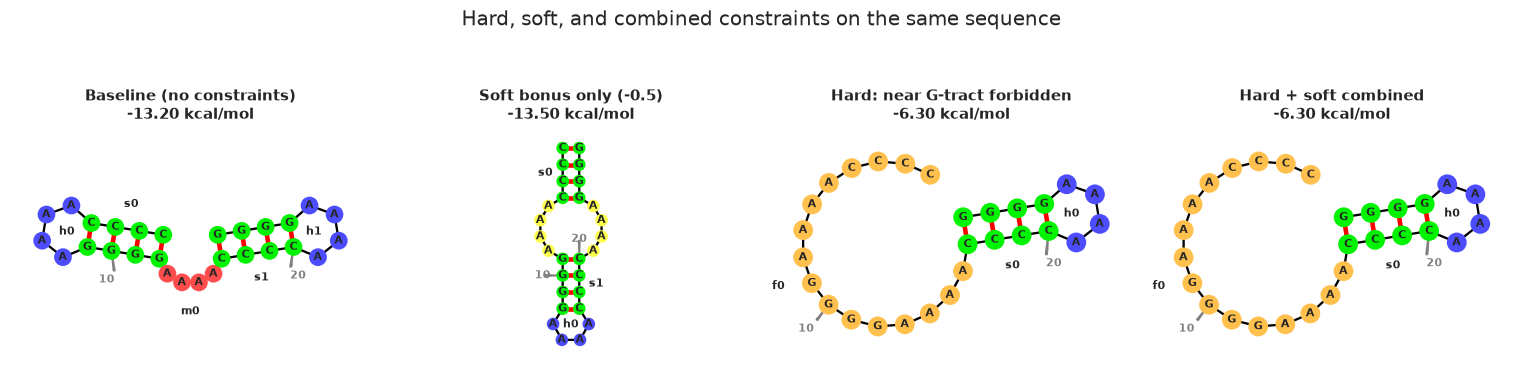

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, row in zip(axes, case_study_df.itertuples()):
    draw_structure(ax, seq_2, row.structure, f"{row.label}\n{row.mfe:.2f} kcal/mol")
fig.suptitle("Hard, soft, and combined constraints on the same sequence", y=1.05, fontsize=13)
fig.tight_layout()
plt.show()


**Reading the figure**: the soft bonus alone is enough to flip to the
far-pairing structure while leaving its energy close to the baseline ($-13.5$
vs. $-13.2$). Forbidding the near G-tract outright is much more disruptive —
with the near G-tract unusable, the second C-tract instead pairs with the far
G-tract for its own hairpin, leaving the first C-tract unpaired entirely and
costing nearly 7 kcal/mol. Adding the soft bonus for pair $(1,28)$ on top of
that hard constraint doesn't help — the $-1.0$ kcal/mol bonus isn't large
enough to make a structure containing that pair cheaper than the $-6.3$
kcal/mol structure the hard constraint already settled on, so the result is
unchanged. **Lesson**: always check which structure your constraints actually
produce, not just whether they were "accepted" — combinations can interact in
non-obvious ways, and a soft bonus only matters if it's large enough to
overcome the *current* gap, which a hard constraint can widen.


## 7. Best practices and common pitfalls

- **All constraint positions are 1-indexed** (`hc_add_bp(1, 28, ...)` refers
  to the first and last bases), while `hc_add_from_db` strings are 0-indexed
  *as Python strings* but represent 1-indexed sequence positions — string
  index 0 is sequence position 1.
- **Hard constraints can only raise (or preserve) the MFE** (Section 2.1) —
  if you see a *lower* energy after adding a hard constraint, double-check
  which fold compound you called `mfe()` on.
- **A hard constraint's energetic cost is directly comparable to base-pair
  probabilities** (Section 4): a small cost means you're targeting a structure
  the unconstrained ensemble already favors; a large cost means you're forcing
  something the ensemble essentially never does.
- **Soft constraints need a bonus bigger than the gap you're trying to
  close** (Section 5) — a bonus smaller than the energy difference between the
  target structure and the current MFE has *no effect at all*, since the
  unconstrained MFE remains optimal.
- **Build a fresh `fold_compound` per constraint set.** Constraints
  (`hc_add_*`, `sc_add_*`) accumulate on the fold compound they're called on;
  reusing one fold compound across "baseline" and "constrained" folds will
  silently carry constraints over.
- **Always inspect the resulting structure**, not just its energy — as
  Section 6 shows, combined constraints can produce structures with
  non-obvious side effects far from the constrained region.


## 8. Summary

- **Hard constraints** (`hc_add_up`, `hc_add_bp`, `hc_add_from_db`) restrict
  the search space $\Omega(x)$; the constrained MFE is always $\geq$ the
  unconstrained MFE.
- **Soft constraints** (`sc_add_up`, `sc_add_bp`) add a pseudo-energy bonus or
  penalty without forbidding anything; a structure becomes optimal once its
  bonus outweighs its energetic disadvantage.
- The **energetic cost of a hard constraint** and the **base-pair probability**
  of the structure it produces (notebook 3) are two views of the same
  quantity — small cost ↔ high probability.
- Constraints **compose**, but combinations can have non-local, non-obvious
  effects — always inspect the resulting structure.

**Next**: [06_comparative_folding.ipynb](06_comparative_folding.ipynb) moves
from a single sequence to **multiple related sequences**, using sequence
covariation across an alignment to predict a consensus structure that is
better supported than any single sequence's MFE alone.


## 9. Exercises

1. In Section 3, the unconstrained MFE has 6 base pairs. How many base pairs
   does `structure_b` (outer helix forbidden) have? Does the 3.5 kcal/mol cost
   roughly match the per-stack costs you computed in
   [02_mfe_folding.ipynb](02_mfe_folding.ipynb)'s loop decomposition?
2. In Section 5, change the constrained pair from $(1, 28)$ to $(2, 27)$ (the
   next base pair in from the ends) and re-run the sweep. Is the switch point
   the same, smaller, or larger? Relate your answer to the base-pair
   probability table from notebook 3.
3. Using `sc_add_up`, add a *penalty* (positive pseudo-energy) for every
   position in the inner hairpin loop of `seq_1` (from notebook 3) being
   unpaired. How large a penalty is needed before the MFE structure changes?
